## Первичный обзор работы с датасетом и процессами

Отключение предупреждений и перенос видимости проекта в папку `EEG-Visual-Experiment`

In [3]:
import os
import warnings

# Нужен для загрузки данных и скриптов
os.chdir("/Data/EEG-Visual-Experiment")
warnings.filterwarnings('ignore')

Подключаем модуль для работы с данными. 

$\text{Dataset}[i] = \begin{bmatrix}
    & \text{mne.Raw EEG} & &\\ 
    & \text{mne.Raw EOG} & &\\ 
    \{ \text{index} & \text{subject\_id} & \text{trial\_id} & \text{task\_type} \}  \\ 
    & \text{pattern\_id} & &\\ 
    & \text{image} 6 \times 6 & & 
\end{bmatrix}$

In [4]:
from Scripts.Data_Loader import EIRDataset

Подгружаем данные, где:
1. `./Generated/Data_Pattern/` - данные о зриетльном восприятие (**perception**)
2. `./Generated/Data_Train/` - данные о зрительном воображении (**imagery**)

In [5]:
path_perception = "./Generated/Data_Pattern/"
ds_perception = EIRDataset(path_perception, task_type="geometric", n_jobs=70)  # Do not set the `n_jobs` = 72 (Can crash the server)

Loading .fif files: 100%|██████████| 360/360 [00:28<00:00, 12.58it/s]


In [6]:
path_imagery = "./Generated/Data_Train/"
ds_imagery = EIRDataset(path_imagery, task_type="geometric", n_jobs=70)  # Do not set the `n_jobs` = 72 (Can crash the server)

Loading .fif files: 100%|██████████| 840/840 [00:35<00:00, 23.59it/s]


Содержание датасетов

In [17]:
len(ds_perception), len(ds_imagery)

(360, 840)

In [18]:
ds_perception[0]

(<Raw | patt_EEG_1.fif, 63 x 26001 (26.0 s), ~12.6 MB, data loaded>,
 <Raw | patt_EOG_1.fif, 5 x 26001 (26.0 s), ~1.0 MB, data loaded>,
 {'index': 0, 'subject_id': 4, 'trial_id': 1, 'task_type': 'geometric'},
 6,
 array([[0, 0, 1, 1, 0, 0],
        [0, 1, 1, 1, 1, 0],
        [0, 1, 0, 0, 1, 0],
        [1, 1, 0, 0, 1, 1],
        [1, 0, 0, 0, 0, 1],
        [1, 1, 1, 1, 1, 1]]))

In [19]:
ds_imagery[0]

(<Raw | exec_EEG_1.fif, 63 x 16001 (16.0 s), ~7.8 MB, data loaded>,
 <Raw | exec_EOG_1.fif, 5 x 16001 (16.0 s), ~636 kB, data loaded>,
 {'index': 0, 'subject_id': 34, 'trial_id': 1, 'task_type': 'geometric'},
 6,
 array([[0, 0, 1, 1, 0, 0],
        [0, 1, 1, 1, 1, 0],
        [0, 1, 0, 0, 1, 0],
        [1, 1, 0, 0, 1, 1],
        [1, 0, 0, 0, 0, 1],
        [1, 1, 1, 1, 1, 1]]))

## MNE и монтаж электродов

Все данные были собраны с EEG прибора с монтажом электродов `./Supplementary/CMA-64_REF.bvef`

In [20]:
import mne

In [21]:
# Load montage schema
montage = mne.channels.read_custom_montage('./Supplementary/CMA-64_REF.bvef')
montage.get_positions()    

{'ch_pos': OrderedDict([('GND',
               array([5.8170723e-18, 9.5000000e-02, 5.8170723e-18])),
              ('REF', array([2.27291122e-18, 3.71194572e-02, 8.74479611e-02])),
              ('Fp1',
               array([-2.93566145e-02,  9.03503690e-02,  5.81707230e-18])),
              ('Fz', array([4.11329127e-18, 6.71751442e-02, 6.71751442e-02])),
              ('F3', array([-0.05177571,  0.06393767,  0.0475    ])),
              ('F7',
               array([-7.68566145e-02,  5.58395990e-02,  5.81707230e-18])),
              ('FT9', array([-0.08316795,  0.02702291, -0.03711946])),
              ('FC5', array([-0.08223207,  0.03322391,  0.03404496])),
              ('FC1', array([-0.03398867,  0.0351963 ,  0.08143089])),
              ('C3', array([-0.06717514, -0.        ,  0.06717514])),
              ('T7', array([-9.5000000e-02, -0.0000000e+00,  5.8170723e-18])),
              ('TP9', array([-0.08316795, -0.02702291, -0.03711946])),
              ('CP5', array([-0.08279938,

In [26]:
# Load EEG from dataset perception
raw, *_ = ds_perception[0]

# Montage schema to data
eeg = raw.copy().pick_types(eeg=True)
eeg.set_montage(montage, on_missing="warn", match_case=False)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


<Raw | patt_EEG_1.fif, 63 x 26001 (26.0 s), ~12.6 MB, data loaded>

## MNE, функции, процессы, визуализации

#### Построение матрицы смежности для заданных электродов

Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 63


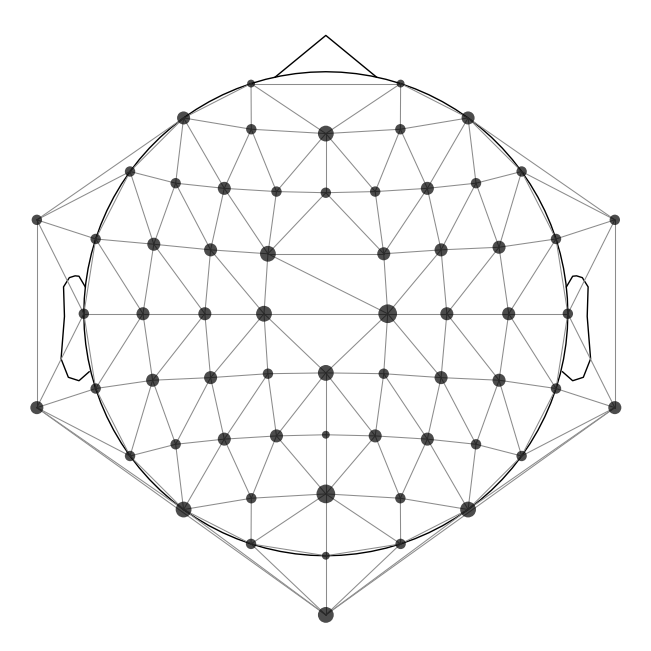

In [33]:
adjacency, ch_names = mne.channels.find_ch_adjacency(eeg.info, 'eeg')
mne.viz.plot_ch_adjacency(eeg.info, adjacency, ch_names)


#### Расчет Power Spectrum Density

In [34]:
eeg_psd = eeg.compute_psd()
eeg_psd

Effective window size : 2.048 (s)


Data type,Power Spectrum
Units,eeg: V²/Hz
Data source,Raw
Dims,"channel, freq"
Estimation method,welch
Number of channels,63
Number of frequency bins,1025
Frequency range,0.00 – 500.00 Hz


Plotting power spectral density (dB=True).


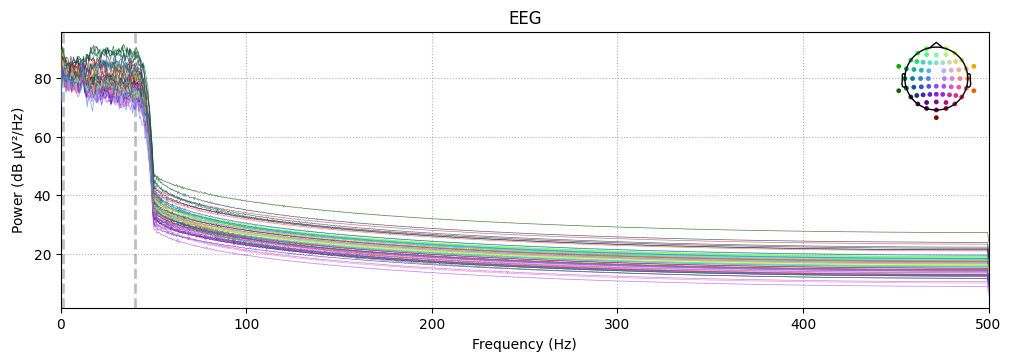

In [36]:
eeg_psd.plot(picks="data", exclude="bads", amplitude=False)


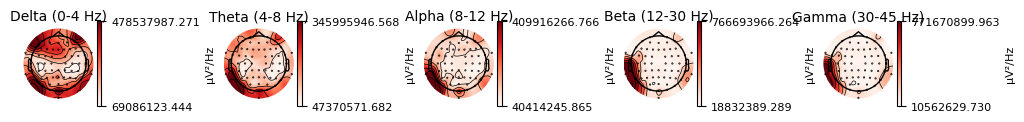

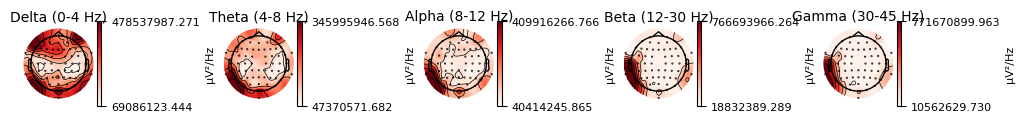

In [38]:
import numpy as np
eeg_psd.plot_topomap(ch_type="eeg", agg_fun=np.median)


#### Частотно Временной анализ

In [56]:
freqs = np.logspace(*np.log10([1, 45]), num=20)
n_cycles = freqs / 2.0

power= eeg.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    decim=3,
    n_jobs=70,
    verbose=True
)
power

[Parallel(n_jobs=70)]: Using backend LokyBackend with 70 concurrent workers.
[Parallel(n_jobs=70)]: Done   7 out of  63 | elapsed:    0.6s remaining:    4.8s
[Parallel(n_jobs=70)]: Done  20 out of  63 | elapsed:    1.3s remaining:    2.8s
[Parallel(n_jobs=70)]: Done  33 out of  63 | elapsed:    1.8s remaining:    1.6s
[Parallel(n_jobs=70)]: Done  46 out of  63 | elapsed:    2.0s remaining:    0.8s
[Parallel(n_jobs=70)]: Done  59 out of  63 | elapsed:   10.9s remaining:    0.7s
[Parallel(n_jobs=70)]: Done  63 out of  63 | elapsed:   11.4s finished


Data type,Power Estimates
Data source,Raw
Dims,"channel, freq, time"
Estimation method,morlet
Number of channels,63
Number of timepoints,8667
Number of frequency bins,20
Frequency range,1.00 – 45.00 Hz


Можно создать совместный график, отображающий как агрегированное значение TFR по каналам, так и топографические карты в определенные моменты времени и на определенных частотах, чтобы быстро получить общее представление об осцилляционных эффектах во времени и пространстве.

No baseline correction applied
No baseline correction applied
No baseline correction applied


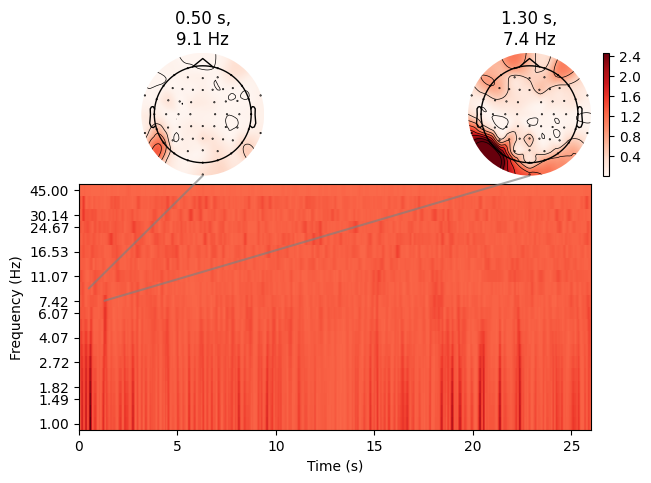

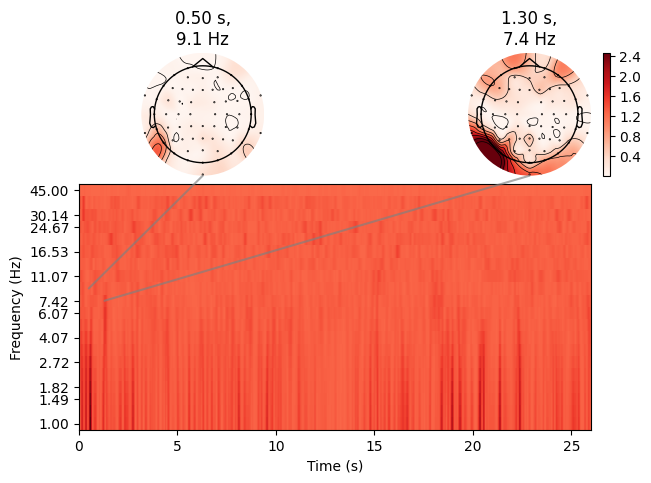

In [57]:
power.plot_joint(mode="mean", timefreqs=[(0.5, 10), (1.3, 8)])


#### Рассчет отношение сигнал/шум (SNR).

In [79]:
tmin = 1.0
tmax = 25.0
fmin = 1.0
fmax = 50.0
sfreq = eeg.info["sfreq"]

spectrum = eeg.compute_psd(
    "welch",
    n_fft=int(sfreq * (tmax - tmin)),
    n_overlap=0,
    n_per_seg=None,
    tmin=tmin,
    tmax=tmax,
    fmin=fmin,
    fmax=fmax,
    window="boxcar",
    verbose=False,
)

psds, freqs = spectrum.get_data(return_freqs=True)

In [80]:
def snr_spectrum(psd, noise_n_neighbor_freqs=1, noise_skip_neighbor_freqs=1):
    """Compute SNR spectrum from PSD spectrum using convolution.

    Parameters
    ----------
    psd : ndarray, shape ([n_trials, n_channels,] n_frequency_bins)
        Data object containing PSD values. Works with arrays as produced by
        MNE's PSD functions or channel/trial subsets.
    noise_n_neighbor_freqs : int
        Number of neighboring frequencies used to compute noise level.
        increment by one to add one frequency bin ON BOTH SIDES
    noise_skip_neighbor_freqs : int
        set this >=1 if you want to exclude the immediately neighboring
        frequency bins in noise level calculation

    Returns
    -------
    snr : ndarray, shape ([n_trials, n_channels,] n_frequency_bins)
        Array containing SNR for all epochs, channels, frequency bins.
        NaN for frequencies on the edges, that do not have enough neighbors on
        one side to calculate SNR.
    """
    # Construct a kernel that calculates the mean of the neighboring
    # frequencies
    averaging_kernel = np.concatenate(
        (
            np.ones(noise_n_neighbor_freqs),
            np.zeros(2 * noise_skip_neighbor_freqs + 1),
            np.ones(noise_n_neighbor_freqs),
        )
    )
    averaging_kernel /= averaging_kernel.sum()

    # Calculate the mean of the neighboring frequencies by convolving with the
    # averaging kernel.
    mean_noise = np.apply_along_axis(
        lambda psd_: np.convolve(psd_, averaging_kernel, mode="valid"), axis=-1, arr=psd
    )

    # The mean is not defined on the edges so we will pad it with nas. The
    # padding needs to be done for the last dimension only so we set it to
    # (0, 0) for the other ones.
    edge_width = noise_n_neighbor_freqs + noise_skip_neighbor_freqs
    pad_width = [(0, 0)] * (mean_noise.ndim - 1) + [(edge_width, edge_width)]
    mean_noise = np.pad(mean_noise, pad_width=pad_width, constant_values=np.nan)

    return psd / mean_noise


In [81]:
snrs = snr_spectrum(psds, noise_n_neighbor_freqs=3, noise_skip_neighbor_freqs=1)

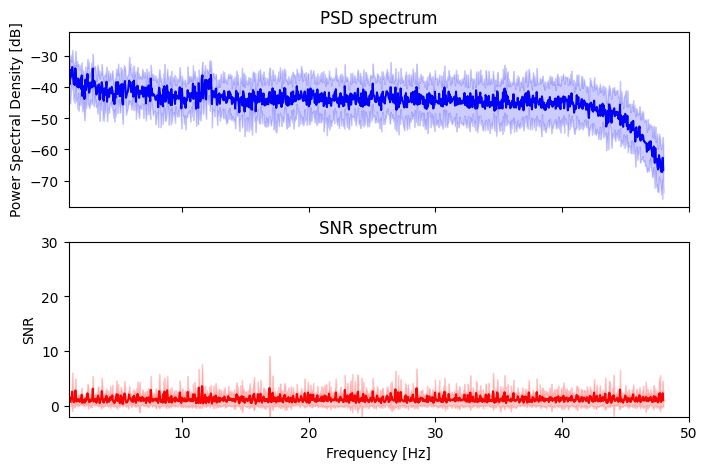

In [82]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, sharex="all", sharey="none", figsize=(8, 5))
freq_range = np.arange(
    np.where(np.floor(freqs) == 1.0)[0][0], np.where(np.ceil(freqs) == fmax - 1)[0][0]
)

psds_plot = 10 * np.log10(psds)
psds_mean = psds_plot.mean(axis=(0))[freq_range]
psds_std = psds_plot.std(axis=(0))[freq_range]
axes[0].plot(freqs[freq_range], psds_mean, color="b")
axes[0].fill_between(
    freqs[freq_range], psds_mean - psds_std, psds_mean + psds_std, color="b", alpha=0.2
)
axes[0].set(title="PSD spectrum", ylabel="Power Spectral Density [dB]")

# SNR spectrum
snr_mean = snrs.mean(axis=(0))[freq_range]
snr_std = snrs.std(axis=(0))[freq_range]

axes[1].plot(freqs[freq_range], snr_mean, color="r")
axes[1].fill_between(
    freqs[freq_range], snr_mean - snr_std, snr_mean + snr_std, color="r", alpha=0.2
)
axes[1].set(
    title="SNR spectrum",
    xlabel="Frequency [Hz]",
    ylabel="SNR",
    ylim=[-2, 30],
    xlim=[fmin, fmax],
)
plt.show()